Patrones de Moiré

El efecto Moiré es una forma particular de aliasing que ocurre cuando se combinan dos patrones repetitivos. Al superponerse, ya sea en la realidad o al digitalizar una imagen, se produce una interferencia que genera nuevas formas visibles como ondas, líneas o figuras que no estaban presentes originalmente. Este fenómeno es común al fotografiar superficies con detalles finos y repetitivos, como telas o pantallas. Aunque normalmente es un efecto no deseado, se puede reducir mediante el uso de filtros antialiasing en cámaras o aplicando técnicas digitales como el suavizado o el muestreo a mayor resolución.

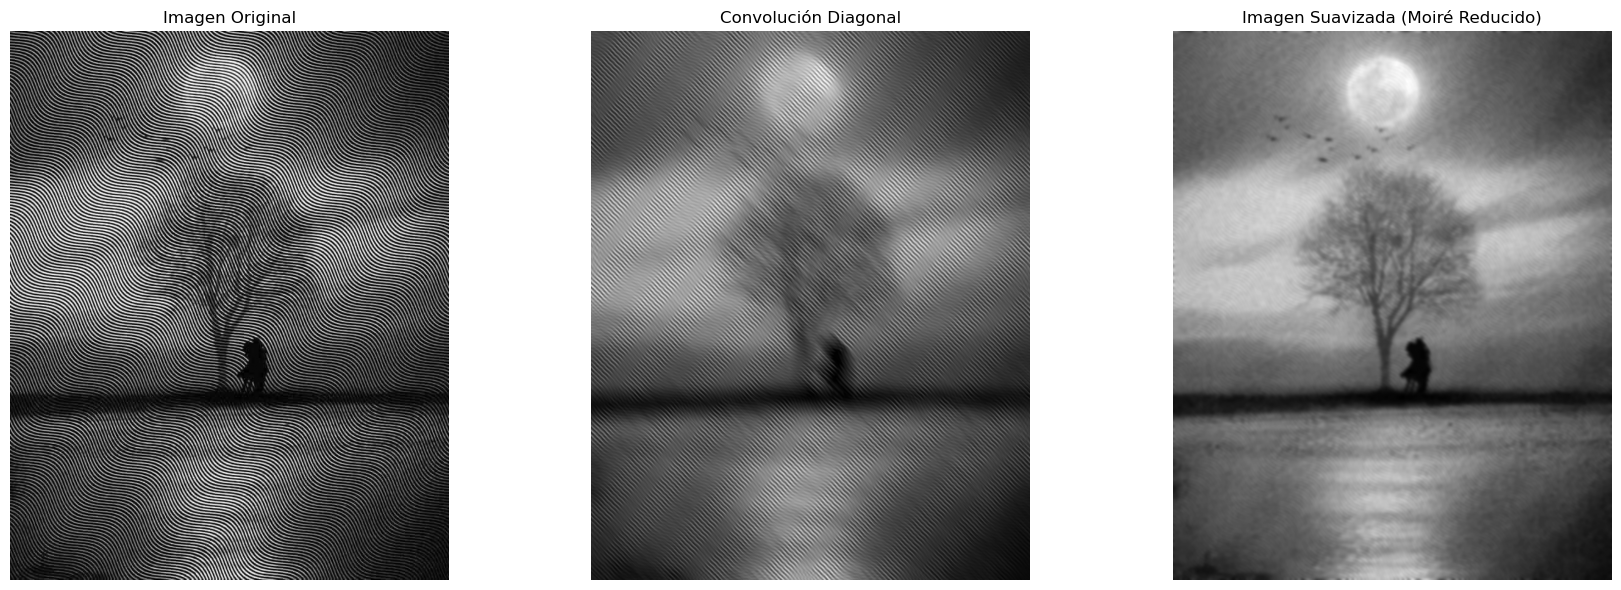

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def crear_kernel_diag(tkernel):
    k = np.zeros((tkernel, tkernel), np.float32)
    for i in range(tkernel):
        k[i, i] = 1.0
    k = k / k.sum()
    return k

def convolucion_media_diag(imagen_gray, tkernel):
    kernel = crear_kernel_diag(tkernel)
    out = cv2.filter2D(imagen_gray.astype(np.float32), -1, kernel)
    out = np.clip(out, 0, 255).astype(np.uint8)
    return out

img_path = 'imgmoire.jpeg'
img = cv2.imread(img_path, 0)


if img is None:
    print(f"No se encontró la imagen '{img_path}'. Usando una imagen de prueba generada.")
    img = np.ones((512, 512), dtype=np.uint8) * 127
    cv2.randn(img, 127, 40) 

tkernel = 31

# 1. Convolución diagonal
img_diag = convolucion_media_diag(img, tkernel)

# 2. Imagen suavizada (para reducir/eliminar el efecto Moiré)
ksize_smooth = 15
img_suavizada = cv2.GaussianBlur(img, (ksize_smooth, ksize_smooth), 0)


plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_diag, cmap='gray')
plt.title('Convolución Diagonal')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_suavizada, cmap='gray')
plt.title('Imagen Suavizada (Moiré Reducido)')
plt.axis('off')

plt.tight_layout()
plt.show()

Aliasing

El aliasing es una distorsión que aparece cuando una señal analógica se convierte en digital sin una frecuencia de muestreo adecuada. Esto sucede cuando no se cumple el teorema de Nyquist-Shannon, lo que impide capturar correctamente los detalles más finos. En imágenes digitales, este problema se observa como bordes irregulares o en forma de “escalera” en líneas curvas o diagonales. También puede generar patrones falsos que no existen en la escena original. Este efecto es más evidente en texturas muy detalladas o repetitivas, donde la resolución del sistema no logra distinguir correctamente cada elemento, produciendo resultados visuales incorrectos.

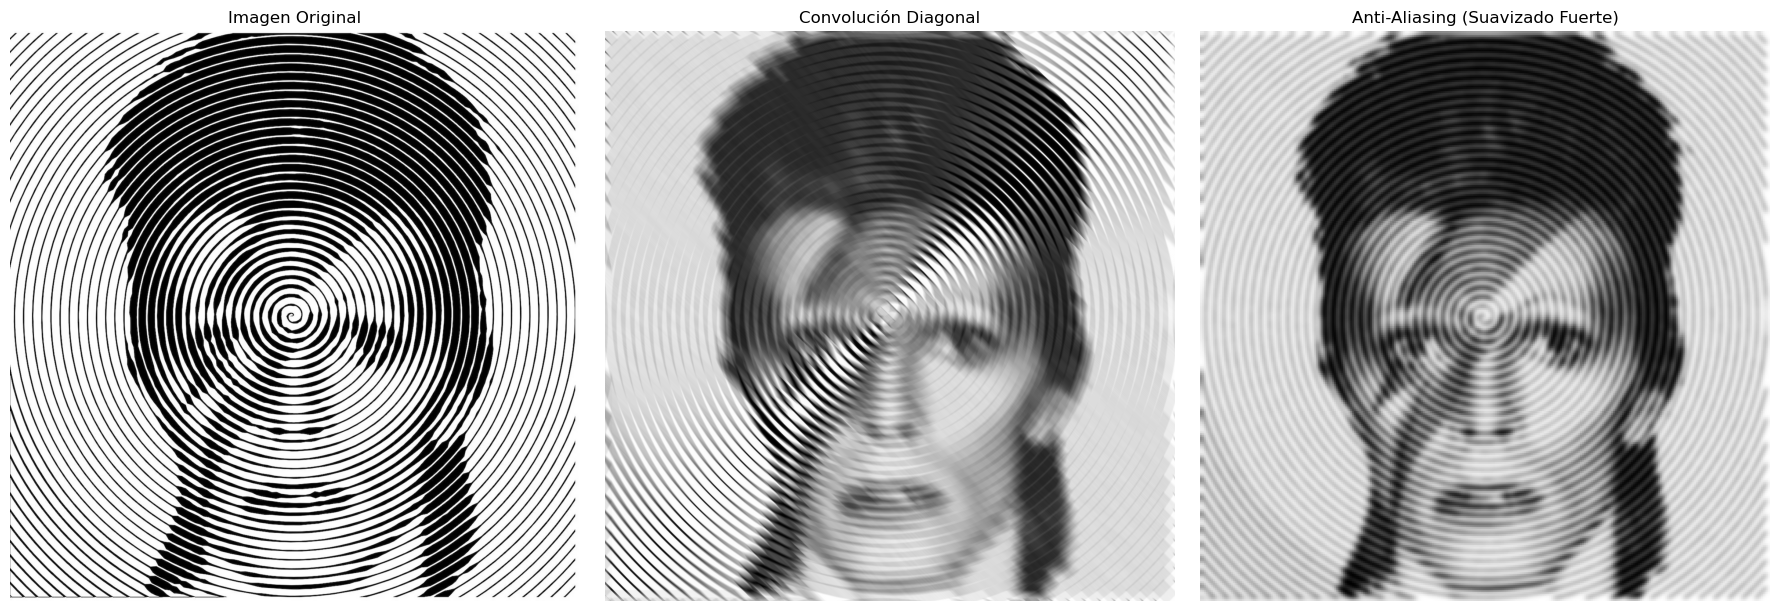

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def crear_kernel_diag(tkernel):
    k = np.zeros((tkernel, tkernel), np.float32)
    for i in range(tkernel):
        k[i, i] = 1.0
    k = k / k.sum()
    return k

def convolucion_media_diag(imagen_gray, tkernel):
    kernel = crear_kernel_diag(tkernel)
    out = cv2.filter2D(imagen_gray.astype(np.float32), -1, kernel)
    out = np.clip(out, 0, 255).astype(np.uint8)
    return out

def downsample_antialiasing(img_gray, scale=0.25, ksize_smooth=35):

    img_blur = cv2.GaussianBlur(img_gray, (ksize_smooth, ksize_smooth), 0)
    h, w = img_blur.shape[:2]
    small = cv2.resize(img_blur, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_NEAREST)
    anti_aliased_img = cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)
    return anti_aliased_img

img_path = 'aliasing.jpg'
img = cv2.imread(img_path, 0)

if img is None:
    print(f"No se encontró la imagen '{img_path}'. Usando una imagen de prueba generada.")
    img = np.ones((512, 512), dtype=np.uint8) * 127
    cv2.randn(img, 127, 40) 

tkernel = 31
scale = 0.25 
ksize_smooth = 35 

# 1. Convolución diagonal 
img_diag = convolucion_media_diag(img, tkernel)

# 2. Imagen con suavizado 
img_antialiasing = downsample_antialiasing(img, scale, ksize_smooth)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_diag, cmap='gray')
plt.title('Convolución Diagonal')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_antialiasing, cmap='gray')
plt.title('Anti-Aliasing (Suavizado Fuerte)')
plt.axis('off')

plt.tight_layout()
plt.show()